In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.signal import welch, decimate, savgol_filter
from nptdms import TdmsFile

%matplotlib inline

In [2]:
tdms_file_path = "data/2025_07_02_MT_DX_MRB/file4.tdms"

base_dir = os.path.dirname(tdms_file_path)
file_stem = os.path.splitext(os.path.basename(tdms_file_path))[0]
plot_dir = os.path.join(base_dir, file_stem)

os.makedirs(plot_dir, exist_ok=True)

tdms_file = TdmsFile.read(tdms_file_path)
group = tdms_file[tdms_file.groups()[0].name]

timestamps = group["PXI1Slot2/ai0"].time_track()
print(f"Max time available in file: {timestamps[-1]:.2f} seconds")

Max time available in file: 239.88 seconds


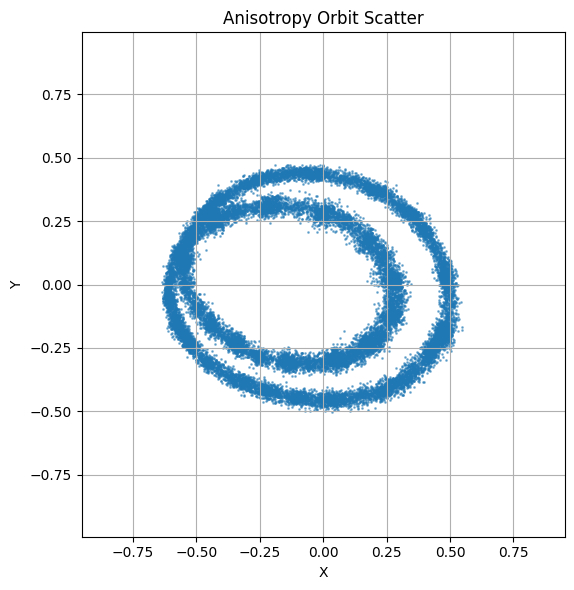

In [3]:
t_start = 100.0
t_end = 100.1
mask = (timestamps >= t_start) & (timestamps <= t_end)
t_masked = timestamps[mask]

c0   = group["PXI1Slot2/ai3"].data[mask]
c45  = group["PXI1Slot2/ai1"].data[mask]
c90  = group["PXI1Slot2/ai0"].data[mask]
c135 = group["PXI1Slot2/ai2"].data[mask]

x = (c0 - c90) / (c0 + c90)
y = (c45 - c135) / (c45 + c135)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=1, alpha=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Anisotropy Orbit Scatter")
plt.axis("equal")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "anisotropy.png"), dpi=300)
plt.show()

In [4]:
fft_time_limit = timestamps[-1]
decimation_factor = 100

mask_raw = timestamps <= fft_time_limit
t_raw = timestamps[mask_raw]
c0_raw = group["PXI1Slot2/ai3"].data[mask_raw]
c45_raw = group["PXI1Slot2/ai1"].data[mask_raw]
c90_raw = group["PXI1Slot2/ai0"].data[mask_raw]
c135_raw = group["PXI1Slot2/ai2"].data[mask_raw]

t_dec = decimate(t_raw, decimation_factor, ftype='fir')
c0_dec = decimate(c0_raw, decimation_factor, ftype='fir')
c45_dec = decimate(c45_raw, decimation_factor, ftype='fir')
c90_dec = decimate(c90_raw, decimation_factor, ftype='fir')
c135_dec = decimate(c135_raw, decimation_factor, ftype='fir')

In [5]:
def fft_speed_trace_with_power(t, signal, fs, config):
    speed = []
    power = []
    times = []

    window_size = config["window_size"]
    step = config["step"]
    nperseg = config["nperseg"]
    nfft = config["nfft"]

    for i in range(0, len(signal) - window_size + 1, step):
        seg = signal[i:i+window_size]
        seg_t = t[i:i+window_size]
        f, Pxx = welch(seg, fs=fs, nperseg=nperseg, nfft=nfft)
        idx = np.argmax(Pxx)
        dom_freq = f[idx]
        peak_power = Pxx[idx]

        speed.append(dom_freq)
        power.append(peak_power)
        times.append(np.mean(seg_t))

    return np.array(times), np.array(speed), np.array(power)

In [6]:
def plot_fft_speed_trace(t, signal, fs, config, label, plot_dir):
    window_size = config["window_size"]
    step = config["step"]
    nperseg = config["nperseg"]
    nfft = config["nfft"]

    times = []
    dom_freqs = []
    peak_power = []

    for i in range(0, len(signal) - window_size + 1, step):
        seg = signal[i:i+window_size]
        seg_t = t[i:i+window_size]
        f, Pxx = welch(seg, fs=fs, nperseg=nperseg, nfft=nfft)
        idx_main = np.argmax(Pxx)
        dom_freqs.append(f[idx_main])
        peak_power.append(Pxx[idx_main])
        times.append(np.mean(seg_t))

    times = np.array(times)
    dom_freqs = np.array(dom_freqs)
    peak_power = np.array(peak_power)

    # === Plot 1 ===
    colors = np.where(peak_power > 1e-5, "tab:blue",
             np.where(peak_power < 1e-7, "tab:orange", "tab:gray"))

    plt.figure(figsize=(12, 4))
    for i in range(len(times) - 1):
        plt.plot(times[i:i+2], dom_freqs[i:i+2], color=colors[i], lw=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Dominant Frequency (Hz)")
    plt.title(f"{label} FFT Speed Trace (Color-coded Confidence)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"fft_speed_colored_confidence_{label}.png"), dpi=300)
    plt.close()

    pd.DataFrame({
        "Time (s)": times,
        "Dominant Frequency (Hz)": dom_freqs,
        "Power": peak_power
    }).to_csv(os.path.join(plot_dir, f"fft_speed_colored_confidence_{label}.csv"), index=False)

    # === Plot 2 ===
    freq_filtered = np.where(peak_power >= 1e-6, dom_freqs, 0)

    plt.figure(figsize=(12, 4))
    plt.plot(times, freq_filtered, lw=2, color="black")
    plt.xlabel("Time (s)")
    plt.ylabel("Dominant Frequency (Hz)")
    plt.title(f"{label} FFT Speed Trace (Weak Segments Zeroed)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"fft_speed_zeroed_{label}.png"), dpi=300)
    plt.close()

    pd.DataFrame({
        "Time (s)": times,
        "Dominant Frequency (Hz)": freq_filtered
    }).to_csv(os.path.join(plot_dir, f"fft_speed_zeroed_{label}.csv"), index=False)

    # === Plot 3 ===
    corrected_freqs = []
    corrected_power = []

    for i in range(len(dom_freqs)):
        seg = signal[i*step : i*step + window_size]
        f, Pxx = welch(seg, fs=fs, nperseg=nperseg, nfft=nfft)

        f_target = dom_freqs[i]
        f_half = f_target / 2
        tolerance = f_target * 0.05

        mask = (f >= f_half - tolerance) & (f <= f_half + tolerance)
        if np.any(mask):
            P_candidates = Pxx[mask]
            f_candidates = f[mask]
            idx_best = np.argmax(P_candidates)
            corrected_freqs.append(f_candidates[idx_best])
            corrected_power.append(P_candidates[idx_best])
        else:
            corrected_freqs.append(f_target)
            corrected_power.append(peak_power[i])

    corrected_freqs = np.array(corrected_freqs)
    corrected_power = np.array(corrected_power)

    corr_colors = np.where(corrected_power > 1e-5, "tab:blue",
                   np.where(corrected_power < 1e-7, "tab:orange", "tab:gray"))

    plt.figure(figsize=(12, 4))
    for i in range(len(times) - 1):
        plt.plot(times[i:i+2], corrected_freqs[i:i+2], color=corr_colors[i], lw=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Corrected Dominant Frequency (Hz)")
    plt.title(f"{label} FFT (Always Take Best ~0.5× Peak)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"fft_speed_corrected_{label}.png"), dpi=300)
    plt.close()

    pd.DataFrame({
        "Time (s)": times,
        "Corrected Frequency (Hz)": corrected_freqs,
        "Corrected Power": corrected_power
    }).to_csv(os.path.join(plot_dir, f"fft_speed_corrected_{label}.csv"), index=False)

    # === Plot 4 ===
    freq_corr_filtered = np.where(corrected_power >= 1e-6, corrected_freqs, 0)

    plt.figure(figsize=(12, 4))
    plt.plot(times, freq_corr_filtered, lw=2, color="black")
    plt.xlabel("Time (s)")
    plt.ylabel("Corrected Dominant Frequency (Hz)")
    plt.title(f"{label} FFT (Corrected + Weak Segments Zeroed)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"fft_speed_corrected_zeroed_{label}.png"), dpi=300)
    plt.close()

    pd.DataFrame({
        "Time (s)": times,
        "Corrected Filtered Frequency (Hz)": freq_corr_filtered
    }).to_csv(os.path.join(plot_dir, f"fft_speed_corrected_zeroed_{label}.csv"), index=False)


In [7]:
fs_raw = 250000
raw_config = {
    "window_size": 80000,
    "step": 40000,
    "nperseg": 80000,
    "nfft": 320000
}

channels_raw = {
    "C0": c0_raw,
    "C45": c45_raw,
    "C90": c90_raw,
    "C135": c135_raw,
    "Itot": c0_raw + c45_raw + c90_raw + c135_raw,
    "X+iY": ((c0_raw - c90_raw) / (c0_raw + c90_raw)) + 1j * ((c45_raw - c135_raw) / (c45_raw + c135_raw))
}

for name, signal in channels_raw.items():
    plot_fft_speed_trace(t_raw, signal, fs_raw, raw_config, label=name + "_raw", plot_dir=plot_dir)

C:\Users\denny\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:1870: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '


In [8]:
# fs_dec = 2500
# dec_config = {
#     "window_size": 100,
#     "step": 50,
#     "nperseg": 100,
#     "nfft": 400
# }

# channels_dec = {
#     "C0": c0_dec,
#     "C45": c45_dec,
#     "C90": c90_dec,
#     "C135": c135_dec,
#     "Itot": c0_dec + c45_dec + c90_dec + c135_dec,
#     "X+iY": ((c0_dec - c90_dec) / (c0_dec + c90_dec)) + 1j * ((c45_dec - c135_dec) / (c45_dec + c135_dec))
# }

# for name, signal in channels_dec.items():
#     plot_fft_speed_trace(t_dec, signal, fs_dec, dec_config, label=name + "_dec", plot_dir=plot_dir)

In [9]:
# savgol_window = 5001
# savgol_order = 2

# channels_raw_smooth = {
#     "C0": savgol_filter(c0_raw, savgol_window, savgol_order),
#     "C45": savgol_filter(c45_raw, savgol_window, savgol_order),
#     "C90": savgol_filter(c90_raw, savgol_window, savgol_order),
#     "C135": savgol_filter(c135_raw, savgol_window, savgol_order)
# }

# channels_raw_smooth["Itot"] = (
#     channels_raw_smooth["C0"] +
#     channels_raw_smooth["C45"] +
#     channels_raw_smooth["C90"] +
#     channels_raw_smooth["C135"]
# )

# channels_raw_smooth["X+iY"] = (
#     (channels_raw_smooth["C0"] - channels_raw_smooth["C90"]) / 
#     (channels_raw_smooth["C0"] + channels_raw_smooth["C90"])
# ) + 1j * (
#     (channels_raw_smooth["C45"] - channels_raw_smooth["C135"]) /
#     (channels_raw_smooth["C45"] + channels_raw_smooth["C135"])
# )

# fs_raw = 250000
# raw_config = {
#     "window_size": 8000,
#     "step": 4000,
#     "nperseg": 8000,
#     "nfft": 32000
# }

# for name, signal in channels_raw_smooth.items():
#     plot_fft_speed_trace(t_raw, signal, fs_raw, raw_config, label=name + "_raw_smooth", plot_dir=plot_dir)


In [10]:
# signal = c135_dec
# time = t_dec
# fs = fs_dec
# config = dec_config

# low_freq_dir = os.path.join(plot_dir, "low_freq_windows")
# os.makedirs(low_freq_dir, exist_ok=True)

# time_limit = 50
# mask = time <= time_limit
# signal = signal[mask]
# time = time[mask]

# window_size = config["window_size"]
# step = config["step"]
# nperseg = config["nperseg"]
# nfft = config["nfft"]

# count = 0
# for i in range(0, len(signal) - window_size + 1, step):
#     seg = signal[i:i+window_size]
#     t_seg = time[i:i+window_size]
#     f, Pxx = welch(seg, fs=fs, nperseg=nperseg, nfft=nfft)
#     dom_freq = f[np.argmax(Pxx)]

#     if dom_freq < 50:
#         fig, axs = plt.subplots(2, 1, figsize=(10, 6))

#         axs[0].plot(t_seg, seg, lw=1.5)
#         axs[0].set_xlabel("Time (s)")
#         axs[0].set_ylabel("Signal")
#         axs[0].set_title(f"Low-Frequency Window {count:03d} – {t_seg[0]:.3f}s to {t_seg[-1]:.3f}s")

#         axs[1].plot(f, Pxx, lw=1.5)
#         axs[1].axvline(dom_freq, color="red", linestyle="--", label=f"Dominant: {dom_freq:.1f} Hz")
#         axs[1].set_xlabel("Frequency (Hz)")
#         axs[1].set_ylabel("Power")
#         axs[1].set_title("FFT Power Spectrum")
#         axs[1].legend()

#         plt.tight_layout()
#         fname = f"window_{count:03d}_{int(dom_freq)}Hz.png"
#         plt.savefig(os.path.join(low_freq_dir, fname), dpi=300)
#         plt.close()
#         count += 1

# print(f"✅ Saved {count} low-frequency plots with spectra to: {low_freq_dir}")

In [11]:
# window_sec = 1.0
# window_samples = int(fs_raw * window_sec)

# total_samples = len(t_raw)
# max_start = total_samples - window_samples

# def plot_raw_channels(start_idx):
#     end_idx = start_idx + window_samples
#     t_slice = t_raw[start_idx:end_idx]
#     c0_slice = c0_raw[start_idx:end_idx]
#     c45_slice = c45_raw[start_idx:end_idx]
#     c90_slice = c90_raw[start_idx:end_idx]
#     c135_slice = c135_raw[start_idx:end_idx]

#     plt.figure(figsize=(12, 4))
#     plt.plot(t_slice, c0_slice, label="C0")
#     plt.plot(t_slice, c45_slice, label="C45")
#     plt.plot(t_slice, c90_slice, label="C90")
#     plt.plot(t_slice, c135_slice, label="C135")
#     plt.xlabel("Time (s)")
#     plt.ylabel("Intensity")
#     plt.title(f"Raw Channels: {t_slice[0]:.2f}s to {t_slice[-1]:.2f}s")
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# slider = widgets.IntSlider(
#     value=0,
#     min=0,
#     max=max_start,
#     step=fs // 10,  # 0.1s step
#     description='Start index',
#     continuous_update=False
# )

# widgets.interact(plot_raw_channels, start_idx=slider)

In [12]:
# window_sec = 1.0
# fs_window = 250000
# window_samples = int(fs_window * window_sec)

# total_samples = len(t_raw)
# max_start = total_samples - window_samples

# def plot_raw_channels(start_idx):
#     end_idx = start_idx + window_samples
#     t_slice = t_raw[start_idx:end_idx]
#     c0_slice = c0_raw[start_idx:end_idx]
#     c0_slice = savgol_filter(c0_slice, savgol_window, savgol_order)
#     c45_slice = c45_raw[start_idx:end_idx]
#     c45_slice = savgol_filter(c45_slice, savgol_window, savgol_order)
#     c90_slice = c90_raw[start_idx:end_idx]
#     c90_slice = savgol_filter(c90_slice, savgol_window, savgol_order)
#     c135_slice = c135_raw[start_idx:end_idx]
#     c135_slice = savgol_filter(c135_slice, savgol_window, savgol_order)

#     plt.figure(figsize=(12, 4))
#     plt.plot(t_slice, c0_slice, label="C0")
#     plt.plot(t_slice, c45_slice, label="C45")
#     plt.plot(t_slice, c90_slice, label="C90")
#     plt.plot(t_slice, c135_slice, label="C135")
#     plt.xlabel("Time (s)")
#     plt.ylabel("Intensity")
#     plt.title(f"Raw Channels: {t_slice[0]:.2f}s to {t_slice[-1]:.2f}s")
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# slider = widgets.IntSlider(
#     value=0,
#     min=0,
#     max=max_start,
#     step=fs_window // 10,  # 0.1s step
#     description='Start index',
#     continuous_update=False
# )

# widgets.interact(plot_raw_channels, start_idx=slider)

In [13]:
# import numpy as np

# npz_path = "results_checked/2025.04.16 patricia/file6/phase_data.npz"  # ← change this to your file

# data = np.load(npz_path)

# print(f"Keys in '{npz_path}':")
# print(list(data.keys()))

# print("\nPreview of arrays:")
# for key in data:
#     arr = data[key]
#     print(f"\n🔹 {key} (shape={arr.shape}, dtype={arr.dtype}):")
#     print(arr[:10])  # show first 10 elements or rows
